In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from cds.pricing.cds_engine import CDS, Params
from cds.data.build_portfolio import spreads_to_df, market_data
from cds.correlation.gaussian_copula import model_index_spread_from_rho, implied_rho

### Load data and replace missing data points
Interpolate companies that have some datapoints

In [ ]:
params = Params(T=5, freq=4, r=0.02, recovery=0.4, coupon=0.05)
cds = CDS(params)
df = spreads_to_df()
df_index = market_data()

df['Date'] = pd.to_datetime(df['Date'])
df_index['date'] = pd.to_datetime(df_index['date'])
df_merged = pd.merge(df, df_index, left_on="Date", right_on="date", how="left")
df_merged["value"] = df_merged["value"] * 10000

df_merged = df_merged.sort_values(["Company", "Date"]).reset_index(drop=True)
df_merged["spread_ratio"] = df_merged["cds_flat_spread"] / df_merged["value"]
df_merged["interpolated_ratio"] = (
    df_merged.groupby("Company")["spread_ratio"]
    .transform(lambda x: x.interpolate(method="linear", limit_direction="both"))
    )
df_merged["normalized_spread"] = df_merged["cds_flat_spread"].fillna(
    df_merged["interpolated_ratio"] * df_merged["value"]
)
df_components = df_merged[["Company", "normalized_spread", "Date"]]
df_components = df_components.rename(columns={"normalized_spread": "cds_flat_spread"})
spreads = df_components.copy() # used later
df_components = df_components.groupby("Date")
df_components.head(n=20)

,Company,cds_flat_spread,Date
0,ADLER Real Estate GmbH,274.580,2025-03-31
1,ADLER Real Estate GmbH,271.700,2025-04-01
2,ADLER Real Estate GmbH,271.695,2025-04-02
3,ADLER Real Estate GmbH,271.740,2025-04-03
4,ADLER Real Estate GmbH,290.645,2025-04-04
...,...,...,...
895,ELO SACA,483.315,2025-05-26
896,ELO SACA,467.990,2025-05-27
897,ELO SACA,467.235,2025-05-28
898,ELO SACA,472.125,2025-05-29


### Calculate and plot the index flat spread for each day

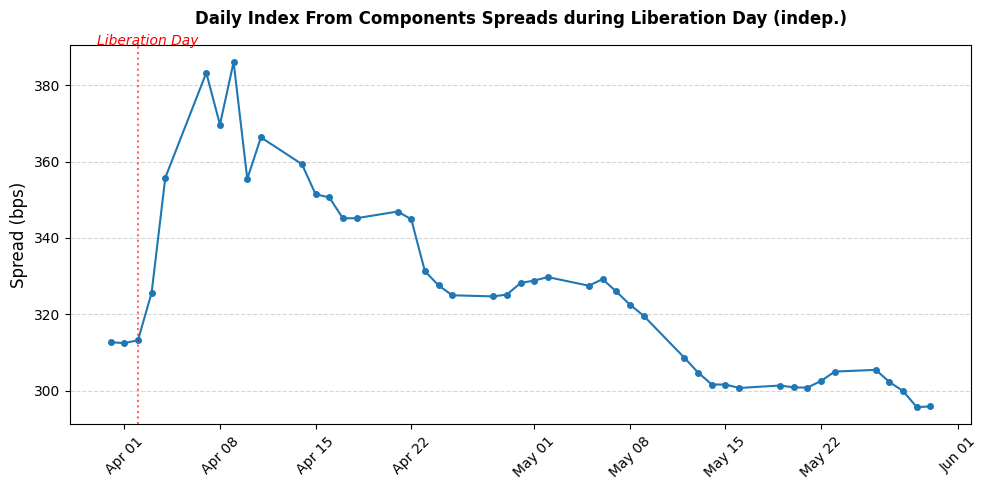

In [9]:
daily_index_spreads = []
for date, df_day in df_components:
    res = cds.index_from_component_spreads(df_day)
    daily_index_spreads.append({
        'date': date,
        'index_from_components': res['index_flat_calc_bp'],
    })
daily_index_spreads_df = pd.DataFrame(daily_index_spreads)

daily_index_spreads_df['date'] = pd.to_datetime(daily_index_spreads_df['date'])
plt.figure(figsize=(10, 5))
plt.plot(
    daily_index_spreads_df['date'], 
    daily_index_spreads_df['index_from_components'], 
    color='#1f77b4', 
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#1f77b4'
)
plt.title('Daily Index From Components Spreads during Liberation Day (indep.)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Spread (bps)', fontsize=12)
plt.xlabel('') 
locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45) 
liberation_day = pd.to_datetime('2025-04-02')
plt.axvline(x=liberation_day, color='red', linestyle=':', alpha=0.6)
plt.text(
    liberation_day - pd.Timedelta(days=3),
    1, 
    'Liberation Day', 
    color='red', 
    fontsize=10, 
    style='italic',
    transform=plt.gca().get_xaxis_transform() 
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Combine with Market Data (Spreads)

In [10]:
df_market_spreads = market_data()
df_market_spreads['date'] = pd.to_datetime(df_market_spreads['date'])
df_market_spreads['value'] = df_market_spreads['value'] * 10000
df_market = df_market_spreads[df_market_spreads['date'].between('2024-04-01', '2025-05-30')]

df = daily_index_spreads_df.merge(df_market, on='date', how='inner')

print(df.head(n=200))

         date  index_from_components       value
0  2025-03-31             312.749316  328.161750
1  2025-04-01             312.514335  326.556100
2  2025-04-02             313.251823  327.288778
3  2025-04-03             325.693423  348.764650
4  2025-04-04             355.769413  388.812143
5  2025-04-07             383.198298  407.216625
6  2025-04-08             369.657167  393.518182
7  2025-04-09             386.001884  427.436667
8  2025-04-10             355.462991  389.662778
9  2025-04-11             366.317972  390.554375
10 2025-04-14             359.308294  372.388250
11 2025-04-15             351.434465  365.871182
12 2025-04-16             350.614911  366.500909
13 2025-04-17             345.144219  366.132778
14 2025-04-18             345.178351  366.132778
15 2025-04-21             346.915914  366.132778
16 2025-04-22             344.914489  365.683278
17 2025-04-23             331.327270  350.633556
18 2025-04-24             327.606911  344.916364
19 2025-04-25       

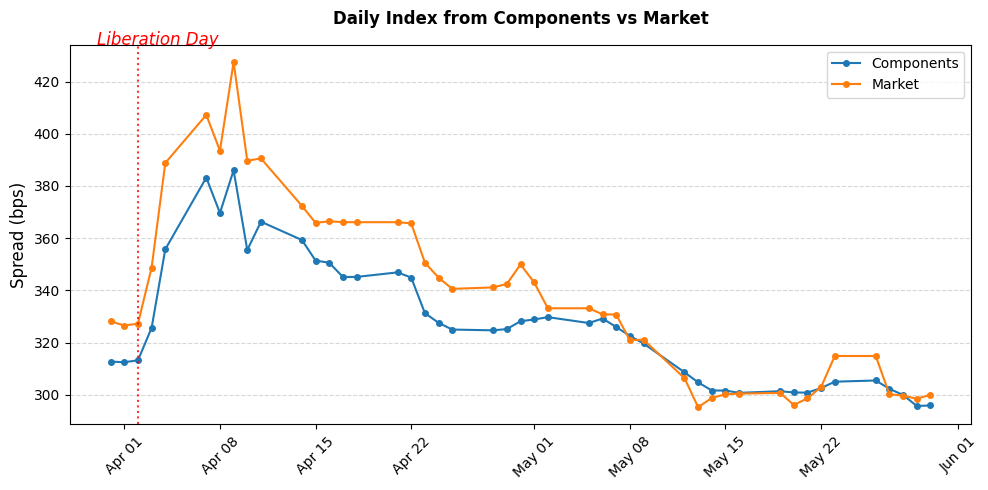

In [11]:
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(10, 5))

plt.plot(
    df['date'], 
    df['index_from_components'], 
    color='#1f77b4', 
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#1f77b4',
    label='Components'
)

plt.plot(
    df['date'], 
    df['value'], 
    color='#ff7f0e', 
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#ff7f0e',
    label='Market'
)
plt.title('Daily Index from Components vs Market', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Spread (bps)', fontsize=12)
plt.xlabel('') 

locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45) 

liberation_day = pd.to_datetime('2025-04-02')

plt.axvline(x=liberation_day, color='red', linestyle=':', alpha=0.8)
plt.text(
    liberation_day - pd.Timedelta(days=3), 
    1,                               
    'Liberation Day', 
    color='red', 
    fontsize=12, 
    style='italic',
    transform=plt.gca().get_xaxis_transform() 
)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Difference

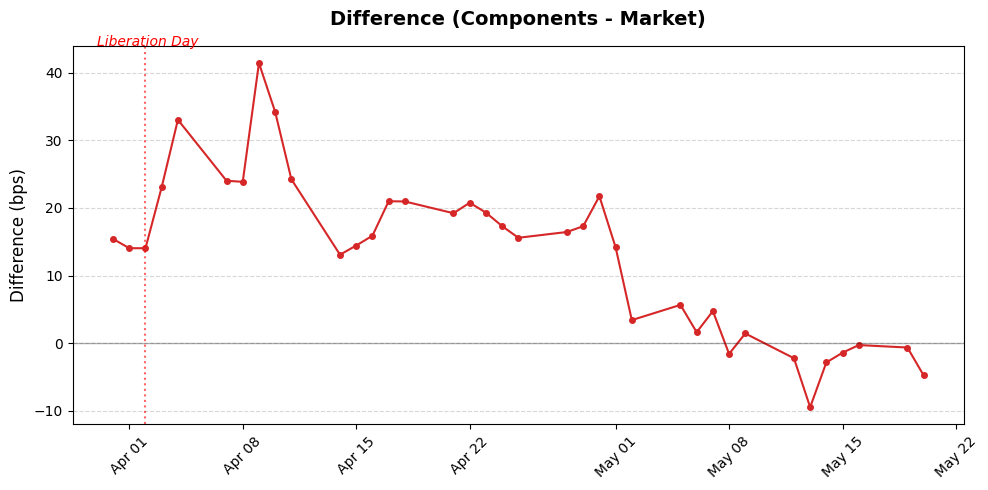

In [12]:
df_diff = df.copy()
df_diff["diff"] = df_diff['value'] - df_diff['index_from_components'] 
df_diff = df_diff[df_diff['date'].between('2024-04-01', '2025-05-20')]

plt.figure(figsize=(10, 5))

plt.plot(
    df_diff['date'], 
    df_diff['diff'], 
    color='#d62728',       
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#d62728',
    label='Basis (Marknad minus Beräknad)'
)

plt.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.3)

plt.title('Difference (Components - Market)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Difference (bps)', fontsize=12)
plt.xlabel('') 

locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45) 

target_date = pd.to_datetime('2025-04-02')

plt.axvline(x=target_date, color='red', linestyle=':', alpha=0.6)
plt.text(
    target_date - pd.Timedelta(days=3), 
    1,                               
    'Liberation Day', 
    color='red', 
    fontsize=10, 
    style='italic',
    transform=plt.gca().get_xaxis_transform() 
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Find implied rho using a one factor Gaussian Copula Model to find and implied correlation factor rho that the market prices in for systemic risk. (Single day)

In [15]:
test_date = pd.Timestamp("2025-04-08")
df_day = spreads[spreads["Date"] == test_date].copy()
market_spread = df.loc[df["date"] == test_date, "value"].iloc[0]

for rho in [0, 0.1, 0.2, 0.4, 0.6]:
    s_model = model_index_spread_from_rho(df_day, rho, alpha=0.05, cds=cds)
    print(f"rho={rho:.2f}, model spread={s_model:.2f}, market={market_spread:.2f}")

rho_star = implied_rho(df_day, market_spread, cds, alpha=0.05)
print(f"Implied rho:", rho_star)

rho=0.00, model spread=370.41, market=393.52
rho=0.10, model spread=693.51, market=393.52
rho=0.20, model spread=890.00, market=393.52
rho=0.40, model spread=1309.35, market=393.52
rho=0.60, model spread=1912.46, market=393.52
Implied rho: 0.0007929609443181108


### Run the correlation for all dates

In [ ]:
df_groups = spreads.groupby("Date")

implied_corr = []

for date, df_day in df_groups:
    market_row = df[df["date"] == date]
    if market_row.empty:
        print("empty row")
        continue

    market_spread=market_row["value"].iloc[0]
    rho = implied_rho(df_day, market_spread, cds, 0.05)

    implied_corr.append({"date": date, "rho": rho})

df_corr = pd.DataFrame(implied_corr)

,date,rho
0,2025-03-31,4.181196e-04
1,2025-04-01,3.450929e-04
2,2025-04-02,3.436789e-04
3,2025-04-03,8.886042e-04
4,2025-04-04,1.602202e-03
5,2025-04-07,7.606334e-04
6,2025-04-08,7.929609e-04
7,2025-04-09,2.238557e-03
8,2025-04-10,1.725909e-03
9,2025-04-11,8.294117e-04


In [17]:
print(df_corr)

         date           rho
0  2025-03-31  4.181196e-04
1  2025-04-01  3.450929e-04
2  2025-04-02  3.436789e-04
3  2025-04-03  8.886042e-04
4  2025-04-04  1.602202e-03
5  2025-04-07  7.606334e-04
6  2025-04-08  7.929609e-04
7  2025-04-09  2.238557e-03
8  2025-04-10  1.725909e-03
9  2025-04-11  8.294117e-04
10 2025-04-14  2.398035e-04
11 2025-04-15  3.063613e-04
12 2025-04-16  3.739107e-04
13 2025-04-17  6.790527e-04
14 2025-04-18  6.766879e-04
15 2025-04-21  5.626282e-04
16 2025-04-22  6.662814e-04
17 2025-04-23  6.131378e-04
18 2025-04-24  4.980489e-04
19 2025-04-25  4.064672e-04
20 2025-04-28  4.539762e-04
21 2025-04-29  5.015680e-04
22 2025-04-30  7.857831e-04
23 2025-05-01  3.269792e-04
24 2025-05-02  1.355653e-05
25 2025-05-05  4.553418e-05
26 2025-05-06  1.586147e-06
27 2025-05-07  3.040857e-05
28 2025-05-08  4.092726e-13
29 2025-05-09  1.118061e-06
30 2025-05-12  4.092726e-13
31 2025-05-13  4.092726e-13
32 2025-05-14  4.092726e-13
33 2025-05-15  4.092726e-13
34 2025-05-16  4.092